# The paper's figures

Every figure in [arXiv:1904.12391](https://arxiv.org/abs/1904.12391) is produced here, and only here.

The plotting style is the group's standard `matplotlibrc`, inlined into the setup cell below rather than shipped as a separate file, with its sizes set for figures included at the paper's `\columnwidth`.

Running this notebook writes all eight PDFs. Set `NUOSC_PAPER_FIGDIR` to write them straight into the paper's directory.

In [1]:
import sys
import os

# Works whether or not the package is installed: these notebooks sit one
# level below the repository root, so src/ is one directory up.
sys.path.insert(0, os.path.abspath(os.path.join('..', 'src')))

import numpy as np
import matplotlib.pyplot as plt

import globaldefs as gd
import oscprob2nu
import oscprob3nu
import oscprob4nu
import hamiltonians2nu
import hamiltonians3nu
import hamiltonians4nu

%matplotlib inline
plt.rcParams.update({'figure.figsize': (7.2, 4.2), 'figure.dpi': 90,
                     'axes.grid': True, 'grid.alpha': 0.3,
                     'font.size': 11, 'legend.frameon': False,
                     # Axes end exactly at the data: no padding beyond
                     # x_min/x_max or y_min/y_max.
                     'axes.xmargin': 0.0, 'axes.ymargin': 0.0})

# The three-flavor vacuum Hamiltonian at the NuFit best fit, normal ordering.
# It is energy-independent; dividing by the energy is what the builders do.
H_VAC_3NU = hamiltonians3nu.hamiltonian_3nu_vacuum_energy_independent(
    gd.S12_NO_BF, gd.S23_NO_BF, gd.S13_NO_BF, gd.DCP_NO_BF,
    gd.D21_NO_BF, gd.D31_NO_BF)

KM = gd.CONV_KM_TO_INV_EV      # multiply a length in km to get eV^-1
GEV = 1.0e9                    # multiply an energy in GeV to get eV

In [2]:
import earth
import slabs
from scipy.linalg import expm
import json
import shutil
from matplotlib.patches import (Rectangle, FancyArrowPatch,
                                Wedge, Polygon, Circle)
import matplotlib.patheffects as pe

# The paper's figures are drawn at \columnwidth -- 229.5 pt = 3.184 in for its
# two-column elsarticle layout -- so that each PDF is included at 1:1 and the
# labels come out at the size they are set at here.
COLW = 229.5/72.27

# The group's standard matplotlibrc, inlined so that the paper's figures do not
# depend on a resource file outside this repository.  The style is unchanged --
# Palatino set through LaTeX, ticks inward on all four sides, framed legends
# with a black border, Type 42 fonts -- but the sizes, which that file chooses
# for standalone 5-inch figures, are set here for figures included at
# \columnwidth beside 10 pt body text.
#
# Setting the labels through LaTeX needs a TeX installation, and Palatino comes
# from that installation rather than from matplotlib.  A machine that only wants
# to check the notebook still runs -- CI, most obviously -- has no reason to
# carry one, so this asks rather than assumes.  With LaTeX the figures are
# exactly the paper's; without it the labels fall back to matplotlib's own
# mathtext, which changes how they are typeset and nothing about what is
# plotted.  Every construct these figures use, \mathbb included, renders under
# both.
HAVE_LATEX = shutil.which('latex') is not None

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Palatino'],
    'text.usetex': HAVE_LATEX,
    'font.size': 8,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 7.5,
    'axes.linewidth': 0.7,
    'lines.linewidth': 1.1,
    'xtick.top': True, 'xtick.bottom': True, 'xtick.direction': 'in',
    'ytick.left': True, 'ytick.right': True, 'ytick.direction': 'in',
    'xtick.major.size': 3.5, 'xtick.minor.size': 2.0,
    'ytick.major.size': 3.5, 'ytick.minor.size': 2.0,
    'xtick.major.width': 0.7, 'xtick.minor.width': 0.7,
    'ytick.major.width': 0.7, 'ytick.minor.width': 0.7,
    'xtick.major.pad': 3.0, 'ytick.major.pad': 3.0,
    'legend.frameon': True, 'legend.edgecolor': 'black',
    'legend.framealpha': 1.0, 'legend.fancybox': False,
    'legend.borderpad': 0.4, 'legend.handlelength': 1.9,
    'legend.handletextpad': 0.5, 'legend.columnspacing': 0.9,
    'legend.labelspacing': 0.35,
    # The shared setup cell above turns the grid on for the exploratory
    # notebooks; the paper's figures, like the group's matplotlibrc, leave
    # it off.
    'axes.grid': False,
    # Axes end exactly at the data in x.  y is left to autoscale: forcing 0-1
    # flattens the three-flavor panels, whose probabilities span a narrow range.
    'axes.xmargin': 0.0,
    'figure.dpi': 150, 'savefig.dpi': 300,
    'savefig.bbox': 'tight', 'savefig.pad_inches': 0.02,
    'pdf.fonttype': 42, 'ps.fonttype': 42,
})

if not HAVE_LATEX:
    # Palatino is supplied by the TeX installation, so asking for it without
    # one earns a missing-font warning per figure and DejaVu Serif anyway.
    plt.rcParams['font.serif'] = plt.rcParamsDefault['font.serif']
    print('latex not found: labels fall back to mathtext, and the serif face '
          'to matplotlib default.  The figures are the paper figures; the '
          'typesetting is not.')

# One-panel figures are square; the stacked ones keep the aspect the paper used.
FIGSIZE_SQUARE = (COLW, COLW)
FIGSIZE_STACK = (COLW, COLW*991.458/565.587)
STYLES = ['-', '--', ':', '-.']

def framed(ax, **kw):
    """A legend with a black frame at the weight of the axes spines."""
    leg = ax.legend(**kw)
    leg.get_frame().set_linewidth(0.7)
    return leg

# Set NUOSC_PAPER_FIGDIR to write the PDFs into the paper's directory.
FIGDIR = os.environ.get('NUOSC_PAPER_FIGDIR', '.')

## Exactness, against an independent reference

The paper's opening figure, and its central claim. The probabilities computed
by the closed forms are compared with direct numerical exponentiation of the
*same* Hamiltonian, `scipy.linalg.expm`, at two, three and four flavors. The
lower panel is the difference. Agreement is at the level of double-precision
round-off, which is what "exact" means here.

2 flavors: max |closed form - expm| = 2.3e-15
3 flavors: max |closed form - expm| = 1.9e-14
4 flavors: max |closed form - expm| = 5.6e-16


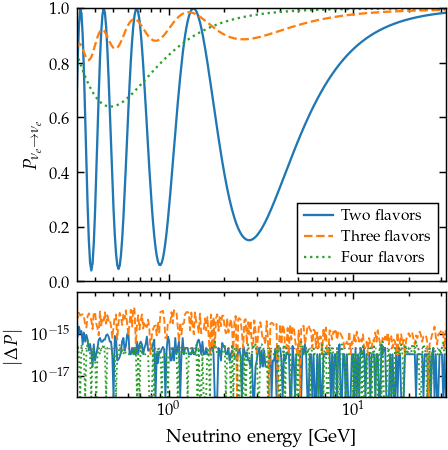

In [3]:
L_LBL = 1300.0*KM      # long baseline, for the two- and three-flavor cases
L_SBL = 0.6*KM         # short baseline, natural for an eV-scale sterile
E_gev = np.logspace(-0.5, 1.5, 300)
E = E_gev*GEV

h2 = hamiltonians2nu.hamiltonian_2nu_matter(
    np.asarray(hamiltonians2nu.hamiltonian_2nu_vacuum_energy_independent(
        gd.S23_NO_BF, gd.D31_NO_BF)), E, gd.VCC_EARTH_CRUST)
h3 = hamiltonians3nu.hamiltonian_3nu_nsi(
    H_VAC_3NU, E, gd.VCC_EARTH_CRUST, gd.EPS_3)
h4 = hamiltonians4nu.hamiltonian_4nu_matter(
    hamiltonians4nu.hamiltonian_4nu_vacuum_energy_independent(
        gd.S12_NO_BF, gd.S23_NO_BF, gd.S13_NO_BF,
        np.sqrt(0.10), np.sqrt(0.10), 0.0,
        gd.DCP_NO_BF, gd.D21_NO_BF, gd.D31_NO_BF, 1.0),
    E, gd.VCC_EARTH_CRUST, gd.VNC_EARTH_CRUST)

p2 = oscprob2nu.probabilities_2nu(h2, L_LBL)[:, 0]
p3 = oscprob3nu.probabilities_3nu(h3, L_LBL)[:, 0]
p4 = oscprob4nu.probabilities_4nu(h4, L_SBL)[:, 0]


def by_expm(h_stack, baseline):
    """P_ee from direct numerical exponentiation of the same Hamiltonian."""
    return np.array([abs(expm(-1j*np.asarray(h)*baseline)[0, 0])**2.0
                     for h in np.asarray(h_stack)])


r2 = by_expm(h2, L_LBL)
r3 = by_expm(h3, L_LBL)
r4 = by_expm(h4, L_SBL)
for n, p, r in ((2, p2, r2), (3, p3, r3), (4, p4, r4)):
    print("%d flavors: max |closed form - expm| = %.1e"
          % (n, np.abs(p-r).max()))

fig, (ax, axr) = plt.subplots(
    2, 1, figsize=(COLW, COLW*1.06), sharex=True,
    gridspec_kw={'height_ratios': [2.6, 1.0], 'hspace': 0.06})

for p, r, lab, ls in ((p2, r2, "Two flavors", "-"),
                      (p3, r3, "Three flavors", "--"),
                      (p4, r4, "Four flavors", ":")):
    # The reference curve lies under the closed-form one to round-off, so
    # plotting it would only overdraw; the lower panel carries the comparison.
    ax.semilogx(E_gev, p, ls, label=lab)
    axr.loglog(E_gev, np.abs(p-r) + 1.0e-18, ls, lw=0.9)

ax.set_ylabel(r"$P_{\nu_e \to \nu_e}$")
ax.set_ylim(0.0, 1.0)
framed(ax, loc="lower right")
axr.axhline(2.2e-16, color="0.45", ls=":", lw=0.7)
axr.set_ylabel(r"$|\Delta P|$")
axr.set_xlabel("Neutrino energy [GeV]")
axr.set_xlim(E_gev[0], E_gev[-1])
axr.set_ylim(1.0e-18, 1.0e-13)
axr.set_yticks([1.0e-17, 1.0e-15])
fig.savefig(os.path.join(FIGDIR, "validation.pdf"))
plt.show()

## Three flavors, four scenarios

Vacuum, constant-density matter, matter with non-standard interactions, and a
CPT-odd Lorentz invariance-violating background, at $L = 1300$ km. All four use
the default parameters in `globaldefs`, so the figure is reproducible from the
repository alone.

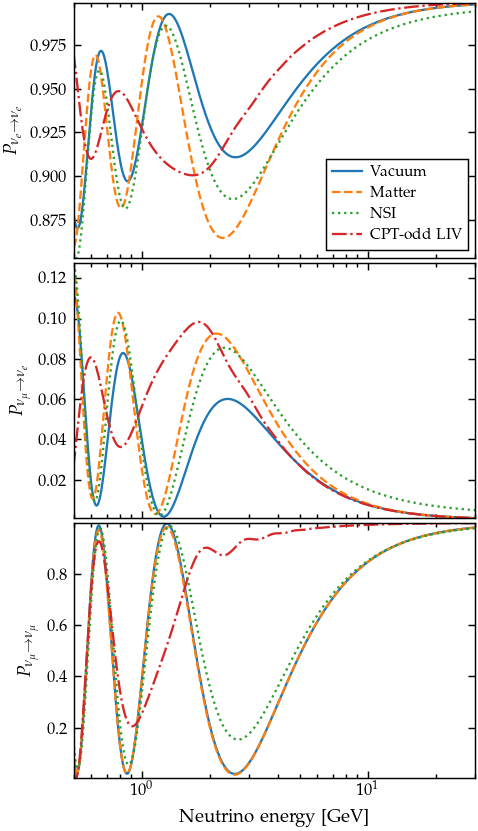

In [4]:
L = 1300.0*KM
E_gev = np.logspace(np.log10(0.5), np.log10(30.0), 400)
E = E_gev*GEV

p = {
    "Vacuum": oscprob3nu.probabilities_3nu(
        np.asarray(H_VAC_3NU)/E[:, None, None], L),
    "Matter": oscprob3nu.probabilities_3nu(
        hamiltonians3nu.hamiltonian_3nu_matter(
            H_VAC_3NU, E, gd.VCC_EARTH_CRUST), L),
    "NSI": oscprob3nu.probabilities_3nu(
        hamiltonians3nu.hamiltonian_3nu_nsi(
            H_VAC_3NU, E, gd.VCC_EARTH_CRUST, gd.EPS_3), L),
    "CPT-odd LIV": oscprob3nu.probabilities_3nu(
        hamiltonians3nu.hamiltonian_3nu_liv(
            H_VAC_3NU, E, gd.SXI12, gd.SXI23, gd.SXI13,
            gd.DXICP, gd.B1, gd.B2, gd.B3, gd.LAMBDA), L),
}

panels = [(0, r"$P_{\nu_e \to \nu_e}$"),
          (3, r"$P_{\nu_\mu \to \nu_e}$"),
          (4, r"$P_{\nu_\mu \to \nu_\mu}$")]

fig, axes = plt.subplots(3, 1, figsize=FIGSIZE_STACK, sharex=True)
for ax, (k, ylabel) in zip(axes, panels):
    for (name, prob), ls in zip(p.items(), STYLES):
        ax.semilogx(E_gev, prob[:, k], ls, label=name)
    ax.set_ylabel(ylabel)
    ax.set_xlim(E_gev[0], E_gev[-1])
framed(axes[0], loc="lower right")
axes[-1].set_xlabel("Neutrino energy [GeV]")
fig.tight_layout(pad=0.3)
fig.savefig(os.path.join(FIGDIR, "prob_3nu_vs_energy_compare.pdf"))
plt.show()

## How the slab composition works

A diagram rather than a calculation: the neutrino crosses slabs of differing
width and density, each solved exactly, and the resulting operators are
multiplied. The ties cross, which is the point --- the slab crossed *first* is
applied first, and so stands *rightmost* in the product.

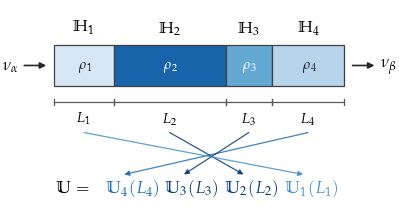

In [5]:
W = [0.9, 1.7, 0.7, 1.1]          # slab widths, arbitrary units
SHADE = [0.16, 0.80, 0.52, 0.30]  # shading, standing in for density
edges = np.concatenate(([0.0], np.cumsum(W)))
total = edges[-1]
cmap = plt.get_cmap("Blues")
fill = [cmap(s) for s in SHADE]
ink = [cmap(np.clip(s + 0.46, 0.62, 0.95)) for s in SHADE]

fig, ax = plt.subplots(figsize=(COLW, COLW*0.56))
ax.set_axis_off()
ax.set_xlim(-0.60, total + 0.60)
ax.set_ylim(-1.16, 0.80)

for k in range(4):
    ax.add_patch(Rectangle((edges[k], 0.0), W[k], 0.40,
                           facecolor=fill[k], edgecolor="0.25", lw=0.6))
    xc = 0.5*(edges[k] + edges[k+1])
    ax.text(xc, 0.48, r"$\mathbb{H}_%d$" % (k+1), ha="center", va="bottom",
            fontsize=7.5)
    ax.text(xc, 0.20, r"$\rho_%d$" % (k+1), ha="center", va="center",
            fontsize=7, color="white" if SHADE[k] > 0.5 else "0.15")
    ax.plot([edges[k], edges[k+1]], [-0.15, -0.15], color="0.35", lw=0.6)
    for e in (edges[k], edges[k+1]):
        ax.plot([e, e], [-0.12, -0.18], color="0.35", lw=0.6)
    ax.text(xc, -0.24, r"$L_%d$" % (k+1), ha="center", va="top", fontsize=7)

for x0, dx in ((-0.52, 0.46), (total + 0.06, 0.46)):
    ax.add_patch(FancyArrowPatch((x0, 0.20), (x0 + dx, 0.20),
                                 arrowstyle="-|>", mutation_scale=6,
                                 lw=0.8, color="0.15"))
ax.text(-0.56, 0.20, r"$\nu_\alpha$", ha="right", va="center", fontsize=8)
ax.text(total + 0.56, 0.20, r"$\nu_\beta$", ha="left", va="center",
        fontsize=8)

y_eq = -0.98
ax.text(0.02, y_eq, r"$\mathbb{U} =$", ha="left", va="center", fontsize=8)
step = (total - 0.78)/4.0
fx = 0.78 + np.arange(4)*step
for k in range(4):
    j = 3 - k                     # factor 4 leftmost, factor 1 rightmost
    ax.text(fx[k], y_eq, r"$\mathbb{U}_%d(L_%d)$" % (j+1, j+1),
            ha="left", va="center", fontsize=8, color=ink[j])
    ax.annotate("", xy=(fx[k] + 0.5*step*0.62, y_eq + 0.14),
                xytext=(0.5*(edges[j] + edges[j+1]), -0.44),
                arrowprops=dict(arrowstyle="-|>", mutation_scale=5,
                                lw=0.6, color=ink[j], alpha=0.85,
                                shrinkA=0, shrinkB=0))

fig.savefig(os.path.join(FIGDIR, "slabs_composition.pdf"))
plt.show()

## An oscillogram through the Earth

Muon-neutrino survival across energy and arrival direction, through the PREM
density profile. Each chord is decomposed into slabs, each solved exactly.

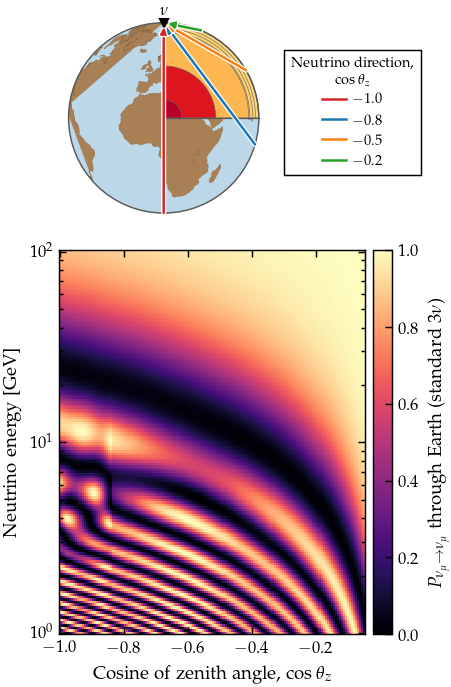

In [6]:
n_e, n_c = 150, 150
E_gev = np.logspace(0.0, 2.0, n_e)
cz = np.linspace(-0.999, -0.05, n_c)

grid = np.empty((n_e, n_c))
for i, e in enumerate(E_gev):
    for j, c in enumerate(cz):
        grid[i, j] = earth.probabilities_3nu_earth(
            H_VAC_3NU, e*GEV, c, n_slabs_per_segment=4)[4]

fig, (axe, ax) = plt.subplots(
    2, 1, figsize=(COLW, COLW*1.78),
    gridspec_kw={"height_ratios": [1.30, 1.9], "hspace": 0.02})

# --- Earth in cutaway, with the PREM layers and a few chords.
# Coastlines are the public-domain GSHHS crude polygons, vendored beside
# this notebook so that the figure needs no mapping library.
with open('coastlines_crude.json') as handle:
    COASTS = json.load(handle)['polygons']

LAT0, LON0 = np.deg2rad(22.0), np.deg2rad(12.0)


def ortho(lon_deg, lat_deg):
    """Orthographic projection; the third return is the visibility mask."""
    lon, lat = np.deg2rad(lon_deg), np.deg2rad(lat_deg)
    cosc = (np.sin(LAT0)*np.sin(lat)
            + np.cos(LAT0)*np.cos(lat)*np.cos(lon - LON0))
    return (np.cos(lat)*np.sin(lon - LON0),
            np.cos(LAT0)*np.sin(lat) - np.sin(LAT0)*np.cos(lat)
            * np.cos(lon - LON0),
            cosc)


R = gd.EARTH_RADIUS
r_edge = np.concatenate(([0.0], earth.PREM_BOUNDARIES, [R]))
r_mid = 0.5*(r_edge[:-1] + r_edge[1:])
rho_shell = np.array([earth.density_prem(r) for r in r_mid])
shade = (rho_shell - rho_shell.min())/(rho_shell.max() - rho_shell.min())

axe.add_patch(Circle((0.0, 0.0), 1.0, facecolor="#bcd7e8", edgecolor="none",
                     zorder=1))
for seg in COASTS:
    seg = np.asarray(seg)
    x, y, cosc = ortho(seg[:, 0], seg[:, 1])
    if (cosc > 0.0).sum() < 3:
        continue
    axe.add_patch(Polygon(np.column_stack([x[cosc > 0.0], y[cosc > 0.0]]),
                          closed=True, facecolor="#a98055",
                          edgecolor="#8a6640", lw=0.15, zorder=2))
axe.add_patch(Circle((0.0, 0.0), 1.0, facecolor="none", edgecolor="0.35",
                     lw=0.7, zorder=6))

# The quarter cutaway, top right, showing the PREM layers.
cmap_e = plt.get_cmap("YlOrRd")
for rb, sh in zip(r_edge[1:][::-1], shade[::-1]):
    axe.add_patch(Wedge((0.0, 0.0), rb/R, 0.0, 90.0, zorder=3, lw=0.3,
                        facecolor=cmap_e(0.10 + 0.78*sh), edgecolor="0.40"))
axe.plot([0.0, 0.0], [0.0, 1.0], color="0.35", lw=0.6, zorder=4)
axe.plot([0.0, 1.0], [0.0, 0.0], color="0.35", lw=0.6, zorder=4)

for c, col in zip((-1.0, -0.8, -0.5, -0.2),
                  ["#d62728", "#1f77b4", "#ff7f0e", "#2ca02c"]):
    phi = 2.0*np.arcsin(min(1.0, -c))
    axe.annotate("", xy=(0.0, 1.0), xytext=(np.sin(phi), np.cos(phi)),
                 zorder=7,
                 arrowprops=dict(arrowstyle="-|>", mutation_scale=6, lw=1.2,
                                 color=col, shrinkA=0, shrinkB=2,
                                 path_effects=[
                                     pe.Stroke(linewidth=2.4,
                                               foreground="white"),
                                     pe.Normal()]))
    axe.plot([], [], "-", color=col, lw=1.2, label=r"$%.1f$" % c)
axe.plot(0.0, 1.0, "v", color="k", ms=4.2, zorder=8)
axe.text(0.0, 1.125, r"$\nu$", color="k", fontsize=8, ha="center",
         va="center", zorder=8)
axe.set_aspect("equal")
axe.set_axis_off()
axe.set_xlim(-1.10, 2.78)
axe.set_ylim(-1.10, 1.21)
leg_e = axe.legend(loc="center right", fontsize=7, borderpad=0.45,
                   handlelength=1.6, handletextpad=0.5, labelspacing=0.4,
                   title="Neutrino direction,\n" + r"$\cos\theta_z$")
leg_e.get_frame().set_linewidth(0.7)
leg_e.get_title().set_fontsize(7)
leg_e.get_title().set_multialignment("center")

mesh = ax.pcolormesh(cz, E_gev, grid, shading="auto", cmap="magma",
                     vmin=0.0, vmax=1.0, rasterized=True)
ax.set_yscale("log")
ax.set_xlabel(r"Cosine of zenith angle, $\cos\theta_z$")
ax.set_ylabel("Neutrino energy [GeV]")
cbar = fig.colorbar(mesh, ax=ax, pad=0.02)
cbar.set_label(r"$P_{\nu_\mu \to \nu_\mu}$ through Earth "
               r"(standard $3\nu$)")
cbar.outline.set_linewidth(0.7)
fig.savefig(os.path.join(FIGDIR, "earth_oscillogram.pdf"))
plt.show()

## The arrangement of matter, not only its mean

Four density profiles with the *same* mean density, and indeed the same
multiset of slabs, give different probabilities. The upper panel shows the
profiles; the lower one, what they do.

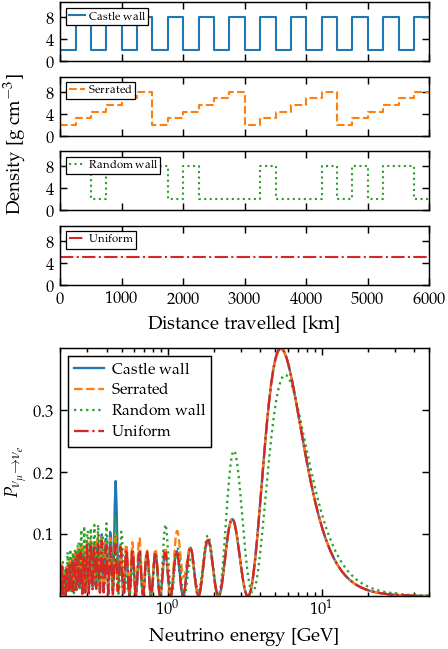

In [7]:
def probabilities_profile(widths_km, densities, energy_ev, h_vac=None):
    """Nine probabilities through an arbitrary matter profile."""
    h_vac = H_VAC_3NU if h_vac is None else h_vac
    vcc = earth.matter_potential(np.asarray(densities, dtype=float))
    H = hamiltonians3nu.hamiltonian_3nu_matter(h_vac, energy_ev, vcc)
    return np.array(slabs.probabilities_3nu_slabs(
        H, np.asarray(widths_km, dtype=float)*KM))


total_km = 6000.0
n_slab = 24
rho_lo, rho_hi = 2.0, 8.0
mean_rho = 0.5*(rho_lo + rho_hi)

widths = np.full(n_slab, total_km/n_slab)
castle = np.where(np.arange(n_slab) % 2 == 0, rho_lo, rho_hi)
serrated = np.tile(np.linspace(rho_lo, rho_hi, 6), 4)
rng = np.random.default_rng(20260801)
# A *permutation* of the castle wall, not a fresh random draw: that guarantees
# the identical multiset of slabs, and so exactly the same mean density, which
# is the whole premise of the comparison.
random_wall = rng.permutation(castle)
uniform = np.full(n_slab, mean_rho)

profiles = [("Castle wall", castle), ("Serrated", serrated),
            ("Random wall", random_wall), ("Uniform", uniform)]
E_gev = np.logspace(-0.7, 1.7, 400)

fig = plt.figure(figsize=(COLW, COLW*1.62))
# Row 4 is left empty, as a gap between the profiles and the probabilities.
gs = fig.add_gridspec(6, 1, height_ratios=[1.0, 1.0, 1.0, 1.0, 0.55, 4.2],
                      hspace=0.18)
axes_p = [fig.add_subplot(gs[i]) for i in range(4)]
ax = fig.add_subplot(gs[5])

edges = np.concatenate(([0.0], np.cumsum(widths)))
for axp, (name, rho), ls, c in zip(axes_p, profiles, STYLES,
                                   ["C0", "C1", "C2", "C3"]):
    axp.step(edges, np.concatenate((rho[:1], rho)), ls, where="pre",
             lw=1.0, color=c, label=name)
    axp.set_xlim(0.0, edges[-1])
    axp.set_ylim(0.0, rho_hi*1.35)
    axp.set_yticks([0.0, 4.0, 8.0])
    leg = axp.legend(loc="upper left", handlelength=1.4, borderpad=0.25,
                     handletextpad=0.4, fontsize=5.5)
    leg.get_frame().set_linewidth(0.6)
    if axp is not axes_p[-1]:
        axp.set_xticklabels([])
axes_p[-1].set_xlabel("Distance travelled [km]")
# One y-label, centred on the four profile panels.
pos_top = axes_p[0].get_position(fig)
pos_bot = axes_p[-1].get_position(fig)
fig.text(0.005, 0.5*(pos_top.y1 + pos_bot.y0), r"Density [g cm$^{-3}$]",
         rotation="vertical", va="center", ha="left", fontsize=9)

for (name, rho), ls, c in zip(profiles, STYLES, ["C0", "C1", "C2", "C3"]):
    p = np.array([probabilities_profile(widths, rho, e*GEV)[3]
                  for e in E_gev])
    ax.semilogx(E_gev, p, ls, color=c, label=name)
ax.set_xlim(E_gev[0], E_gev[-1])
ax.set_xlabel("Neutrino energy [GeV]")
ax.set_ylabel(r"$P_{\nu_\mu \to \nu_e}$")
leg = ax.legend(loc="upper left", ncol=1, fontsize=7.5)
leg.get_frame().set_linewidth(0.7)
fig.savefig(os.path.join(FIGDIR, "density_arrangement.pdf"))
plt.show()

## A 3+1 sterile resonance through the Earth

Four flavors, antineutrinos, through the Earth: the matter resonance that a
three-flavor treatment cannot produce at all.

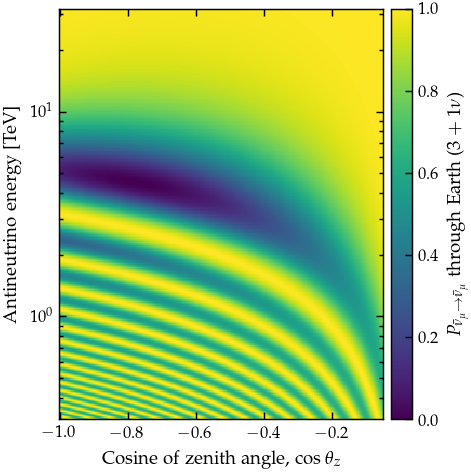

In [8]:
DM41 = 1.0                       # [eV^2]
S14 = S24 = np.sqrt(0.10)
S34 = 0.0

H_VAC_4NU = hamiltonians4nu.hamiltonian_4nu_vacuum_energy_independent(
    gd.S12_NO_BF, gd.S23_NO_BF, gd.S13_NO_BF, S14, S24, S34,
    gd.DCP_NO_BF, gd.D21_NO_BF, gd.D31_NO_BF, DM41)

n_e, n_c = 300, 300
E_tev = np.logspace(-0.5, 1.5, n_e)          # 0.3 - 30 TeV
costhz = np.linspace(-1.0, -0.05, n_c)

# Antineutrinos: conjugate the vacuum term and flip both potentials.  One
# average mantle density here, so the whole grid is a single broadcast call.
rho_mantle = 4.5                              # [g cm^-3]
vcc = earth.matter_potential(rho_mantle)
H_bar = hamiltonians4nu.hamiltonian_4nu_matter(
    np.conj(H_VAC_4NU), E_tev[:, None]*1.0e3*GEV,
    -vcc, -gd.VNC_EARTH_CRUST*rho_mantle/3.0)

L_grid = np.array([earth.distance_traveled_inside_earth(c)
                   for c in costhz])*KM
grid = oscprob4nu.probabilities_4nu(H_bar, L_grid[None, :])

fig, ax = plt.subplots(figsize=FIGSIZE_SQUARE)
mesh = ax.pcolormesh(costhz, E_tev, grid[:, :, 5], shading="auto",
                     cmap="viridis", vmin=0.0, vmax=1.0, rasterized=True)
ax.set_yscale("log")
ax.set_xlabel(r"Cosine of zenith angle, $\cos\theta_z$")
ax.set_ylabel("Antineutrino energy [TeV]")
cbar = fig.colorbar(mesh, ax=ax, pad=0.02)
cbar.set_label(r"$P_{\bar\nu_\mu \to \bar\nu_\mu}$ through Earth "
               r"($3+1\nu$)")
cbar.outline.set_linewidth(0.7)
fig.tight_layout(pad=0.3)
fig.savefig(os.path.join(FIGDIR, "sterile_earth_oscillogram.pdf"))
plt.show()

## How the pieces fit together

A map of the library: what each module is responsible for, and how a
Hamiltonian becomes a probability.

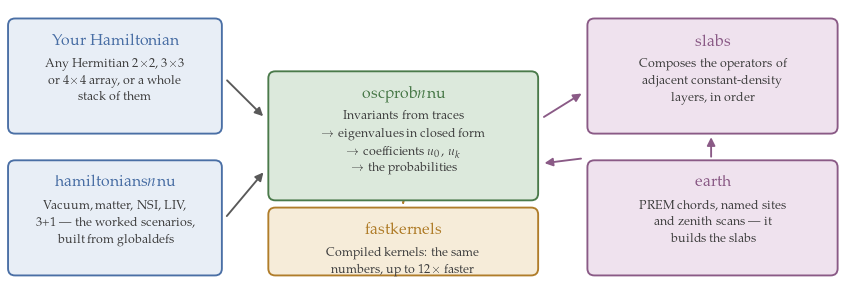

In [9]:
from matplotlib.patches import FancyBboxPatch

# Two columns wide: TEXTW is the paper's \textwidth.
TEXTW = 522.0/72.27

fig, axd = plt.subplots(figsize=(TEXTW, TEXTW*0.34))
axd.set_axis_off()
axd.set_xlim(0.0, 30.0)
axd.set_ylim(0.0, 10.2)

C_IN, C_CORE, C_ACC, C_COMP = "#e8eef6", "#dce9dc", "#f6ecd9", "#efe2ee"
E_IN, E_CORE, E_ACC, E_COMP = "#4a6fa5", "#4a7a4a", "#b07d2a", "#8a5a86"


def box(x, y, w, h, face, edge, title, body):
    axd.add_patch(FancyBboxPatch(
        (x, y), w, h, boxstyle="round,pad=0.12,rounding_size=0.25",
        facecolor=face, edgecolor=edge, lw=0.9, zorder=2))
    axd.text(x + w/2.0, y + h - 0.42, title, ha="center", va="top",
             fontsize=7.6, color=edge, zorder=3,
             fontfamily="monospace" if title[0].islower() else None)
    if body:
        axd.text(x + w/2.0, y + h - 1.30, body, ha="center", va="top",
                 fontsize=6.0, color="0.25", zorder=3, linespacing=1.5)


def arrow(x0, y0, x1, y1, color="0.35", ls="-"):
    axd.annotate("", xy=(x1, y1), xytext=(x0, y0), zorder=1,
                 arrowprops=dict(arrowstyle="-|>", mutation_scale=8, lw=0.9,
                                 color=color, linestyle=ls, shrinkA=2,
                                 shrinkB=2))


# Left: what goes in.  Middle: the library proper.  Right: layered matter.
box(0.3, 5.6, 7.4, 3.9, C_IN, E_IN, "Your Hamiltonian",
    "Any Hermitian $2{\\times}2$, $3{\\times}3$\nor $4{\\times}4$ array, or a whole\nstack of them")
box(0.3, 0.5, 7.4, 3.9, C_IN, E_IN, "hamiltonians$n$nu",
    "Vacuum, matter, NSI, LIV,\n3+1 --- the worked scenarios,\nbuilt from globaldefs")

# The green box was 5.0 tall for four lines of body, leaving its lower half
# empty, and its rounded corner met the orange box's: 2.6 against 2.5, minus
# 0.12 of padding each, overlapped them.  Shortened, and moved up to leave a
# clear 0.5 between the two.
box(9.6, 3.2, 9.4, 4.4, C_CORE, E_CORE, "oscprob$n$nu",
    "Invariants from traces\n"
    "$\\rightarrow$ eigenvalues in closed form\n"
    "$\\rightarrow$ coefficients $u_0,\\, u_k$\n"
    "$\\rightarrow$ the probabilities")
box(9.6, 0.5, 9.4, 2.2, C_ACC, E_ACC, "fastkernels",
    "Compiled kernels: the same\nnumbers, up to $12{\\times}$ faster")

box(21.0, 5.6, 8.7, 3.9, C_COMP, E_COMP, "slabs",
    "Composes the operators of\nadjacent constant-density\nlayers, in order")
box(21.0, 0.5, 8.7, 3.9, C_COMP, E_COMP, "earth",
    "PREM chords, named sites\nand zenith scans --- it\nbuilds the slabs")

arrow(7.9, 7.5, 9.4, 6.0)
arrow(7.9, 2.4, 9.4, 4.2)
arrow(14.3, 3.15, 14.3, 2.80, color=E_ACC, ls="--")
arrow(19.2, 6.0, 20.8, 7.0, color=E_COMP)
arrow(20.8, 4.6, 19.2, 4.4, color=E_COMP)
arrow(25.3, 4.5, 25.3, 5.5, color=E_COMP)
fig.savefig(os.path.join(FIGDIR, "architecture.pdf"),
            bbox_inches="tight", pad_inches=0.02)
plt.show()

## Speed and accuracy, against five other codes

Every code here solves the *same* problem and is refereed by the *same*
arbitrary-precision reference, so that none of them is its own judge.

The external numbers are frozen in `tests/speed_accuracy.json`; the cell below
records exactly how each was obtained, so the comparison can be reproduced or
disputed without guessing what was run.

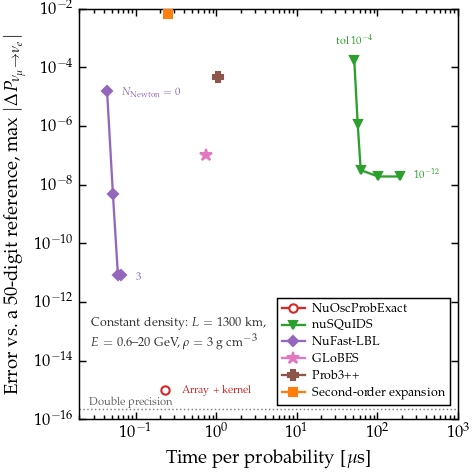

In [10]:
# ---------------------------------------------------------------------------
# Provenance of the external numbers.  None of these codes is needed to run
# this notebook: the results are frozen in tests/speed_accuracy.json.  What
# follows is exactly what was done to produce them, on Linux, August 2026.
#
# TWO CONVENTIONS ARE MATCHED FIRST, or the comparison measures bookkeeping
# rather than physics:
#
#   Matter potential.  This library takes n_e = Y_e rho / m_bar, with m_bar the
#   mean free-nucleon mass; the others take rho N_A Y_e.  The ratio is the
#   nuclear mass defect,
#       scale = (CONV_G_TO_EV/((MASS_PROTON+MASS_NEUTRON)/2)) / N_A = 0.99209
#   and each external code is handed rho*scale = 2.97628 g/cm^3 so that all
#   propagate with the same V_CC.  (For GLoBES this factor was *found* by
#   scanning the density, and the minimum landed on 0.99209 to a part in 1e7 --
#   an independent check that the reasoning above is right.)
#
#   Length unit.  The codes disagree on hbar*c in the 7th digit:
#       this library  5.0677300000e9   eV^-1 per km
#       nuSQuIDS      5.0677307162e9
#       NuFast-LBL    5.0677302143e9   ( = 1e3 / 1.97327e-7 )
#   so each is given the baseline in km that reproduces *our* L in eV^-1.
#   NuFast and Prob3++ and GLoBES get 1299.999945 km instead of 1300.
#
# THE REFEREE.  Accuracy is measured against a 50-digit mpmath matrix
# exponential of the same Hamiltonian:
#     mp.mp.dps = 50;  U = mp.expm(-1j*M*mp.mpf(L));  P = abs(U[0,1])**2
# This library agrees with it to 4e-17, which is why it can be plotted at
# "double precision" rather than at zero.
#
# ---------------------------------------------------------------------------
# nuSQuIDS 1.13.3 -- manylinux wheel, no compiler needed:
#     pip install nusquids            # imports as `nuSQuIDS`
#   Multiple-energy mode, Set_rel_error = Set_abs_error swept over
#   1e-4 ... 1e-12.  Timed through the Python interface, including building
#   the solver and reading the results back.  Note its own default tolerance
#   is far tighter and ~40x slower than an explicit 1e-12.
#
# NuFast-LBL -- header-only C++, not on PyPI:
#     git clone https://github.com/PeterDenton/NuFast-LBL.git
#     g++ -Ofast -ffast-math driver.cpp -o driver
#   Probability_Matter_LBL(...), sweeping N_Newton = 0,1,2,3.  Timed inside
#   C++, best of five, with no Python in the loop.  rhoYe = 1.488737 (that is
#   3*0.5*0.99209).  N_Newton = 0 is its default and is a truncation, not an
#   error: two steps reach 8e-12.
#
# GLoBES 3.2.18 -- needs GSL (2.7.1 here):
#     curl -O https://www.mpi-hd.mpg.de/personalhomes/globes/download/globes-3.2.18.tar.gz
#     tar xzf globes-3.2.18.tar.gz && cd globes-3.2.18
#     ./configure --prefix=$PREFIX --with-gsl-prefix=/usr && make && make install
#     gcc -O2 -I$PREFIX/include drv.c -L$PREFIX/lib -lglobes -lgsl -lgslcblas -lm
#   glbConstantDensityProbability(2, 1, +1, E, L, rho), after glbDefineParams
#   with angles as arcsin(sqrt(sin^2 theta)) and glbSetOscillationParameters.
#
# Prob3++ -- C++; mosc.c and mosc3.c must be compiled as C, not C++:
#     git clone https://github.com/rogerwendell/Prob3plusplus.git
#     gcc -O2 -c mosc.c mosc3.c ; g++ -O2 -c EarthDensity.cc BargerPropagator.cc
#     g++ -O2 drv.cpp mosc.o mosc3.o EarthDensity.o BargerPropagator.o
#   BargerPropagator::SetMNS(s12sq, s13sq, s23sq, dm21, dmAtm, dcp, E, true, 1)
#   then propagateLinear(1, L, rho) and GetProb(2, 1).
#   CAUTION: the fifth argument is Dm2_32, NOT Dm2_31.  Passing Dm2_31 leaves a
#   1.7e-2 disagreement that no density rescaling will remove; with
#   Dm2_32 = 2.525e-3 - 7.39e-5 it drops to 4.5e-5.
#
# nuCraft r22 -- pure Python, installs by unpacking:
#     curl -O https://nucraft.hepforge.org/nuCraft-r22.tar.gz && tar xzf ...
#   NOT included here: its interface is (PDG type, energy, zenith angle) and it
#   propagates through its own Earth model, with no constant-density mode, so
#   it belongs in an Earth comparison rather than this one.  Two of its
#   conventions would need matching there: default electron fractions
#   y = (0.4957, 0.4656, 0.4656) rather than 0.5, and a default rICore of
#   1121.5 km against the 1221.5 km in its own PREM density table.
# ---------------------------------------------------------------------------

import json

with open(os.path.join('..', 'tests', 'speed_accuracy.json')) as handle:
    sa = json.load(handle)

# The same colours, markers and layout as the two Earth planes, so that a
# code keeps its identity across all three.  This library shows only the
# batched-plus-kernel point: the other two routes are what the performance
# figure is for, and here they would be three labels on one horizontal line.
STYLE = {"NuOscProbExact": ("-o", "C3", 4.0),
         "nuSQuIDS": ("-v", "C2", 3.6),
         "NuFast-LBL": ("-D", "C4", 3.2),
         "GLoBES": ("-*", "C6", 6.0),
         "Prob3++": ("-P", "C5", 4.4),
         "Second-order expansion": ("-s", "C1", 3.6)}
DRAWN = {"NuOscProbExact": ("Array + kernel",)}

fig, ax = plt.subplots(figsize=FIGSIZE_SQUARE)
for series in sa["series"]:
    marker, colour, size = STYLE[series["name"]]
    keep = DRAWN.get(series["name"])
    points = [q for q in series["points"]
              if keep is None or q["label"] in keep]
    t = [q["us_per_probability"] for q in points]
    e = [q["max_abs_error"] for q in points]
    kw = dict(ms=size, color=colour, label=series["name"], zorder=4)
    if series["name"] == "NuOscProbExact":
        kw.update(mfc="white", mew=1.0, zorder=5)
    ax.loglog(t, e, marker, **kw)

# What is varied along each curve, at both ends where there are two.
for lab, x, y, dx, dy, c, ha in (
        (r"tol $10^{-4}$", 51.61, 1.83e-04, 0, 7, "C2", "center"),
        (r"$10^{-12}$", 189.37, 1.89e-08, 7, -1, "C2", "left"),
        (r"$N_{\rm Newton} = 0$", 0.044, 1.53e-05, 7, -2, "C4", "left"),
        (r"$3$", 0.066, 8.30e-12, 7, -2, "C4", "left")):
    ax.annotate(lab, xy=(x, y), xytext=(dx, dy), textcoords="offset points",
                fontsize=5.2, color=c, ha=ha)

ax.axhline(2.2e-16, color="0.5", ls=":", lw=0.7, zorder=1)
ax.text(2.6e-2, 3.2e-16, "Double precision", fontsize=5.4, color="0.4")
# This panel's data does not leave the same corners free as the Earth ones:
# the single NuOscProbExact point sits at the bottom left and nuSQuIDS runs
# along the top right, so the subtitle goes just above the former and the
# legend into the empty bottom right.
ax.text(0.03, 0.17, "Constant density:  $L = 1300$ km,\n"
        r"$E = 0.6$--$20$ GeV,  $\rho = 3$ g cm$^{-3}$",
        transform=ax.transAxes, ha="left", va="bottom", fontsize=6.0,
        color="0.2", linespacing=1.4)
ax.annotate("Array + kernel", xy=(0.230, 9.71e-16), xytext=(8, -1),
            textcoords="offset points", fontsize=5.2, color="C3", ha="left")
ax.set_xlabel(r"Time per probability [$\mu$s]")
ax.set_ylabel(r"Error vs.\ a 50-digit reference,  "
              r"max $|\Delta P_{\nu_\mu \to \nu_e}|$")
ax.set_xlim(2.0e-2, 1.0e3)
ax.set_ylim(1.0e-16, 1.0e-2)
leg = ax.legend(loc="lower right", bbox_to_anchor=(0.995, 0.02),
                fontsize=6.0)
leg.get_frame().set_linewidth(0.7)
fig.tight_layout(pad=0.3)
fig.savefig(os.path.join(FIGDIR, "speed_accuracy.pdf"))
plt.show()

## Speed and accuracy through the Earth

The same plane as above, on the PREM profile rather than at constant density,
at three flavors and at 3+1.

These two measure something different from the figure above, and the
difference is the whole point of them. At constant density there is an exact
answer, and the figure measures how closely each code evaluates it: the floor
is round-off. Through the Earth the density varies continuously, and *every*
code approximates the profile, this one included. So the reference here is a
**converged** PREM solution rather than an exact one, and each code sits where
its treatment of the profile puts it, not where the accuracy of its
probability formula would.

The consequence is that this library is a curve rather than a horizontal line,
with `n_slabs_per_segment` as its dial. That is more informative than a line:
the dial is what a user actually turns, and it keeps converging — second order
in the slab width — through the region where both external codes flatten out.

The external numbers are frozen in `tests/prem_speed_accuracy.json`.

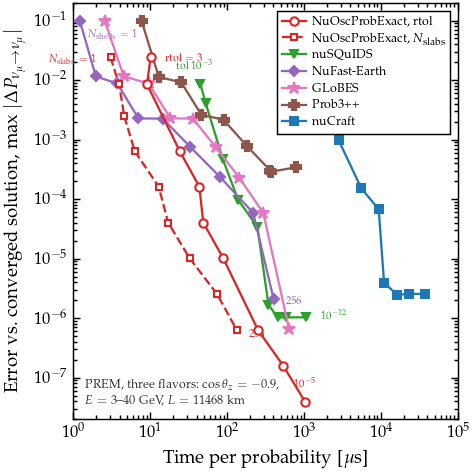

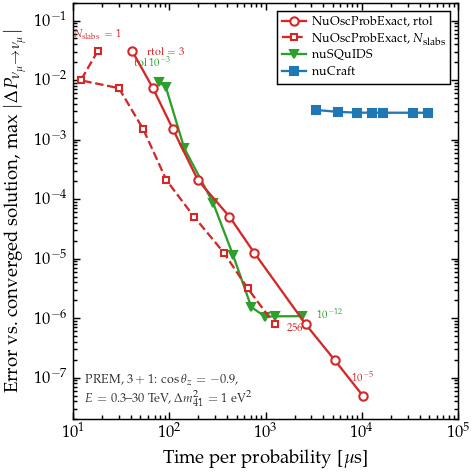

In [11]:
# ---------------------------------------------------------------------------
# Provenance.  Neither external code is needed to run this notebook: the
# results are frozen in tests/prem_speed_accuracy.json.  The generator,
# tests/prem_scan.py, carries the full account in its module docstring --
# every convention matched, how each was established, and the three
# Python 2 remnants in nuCraft r22.  In brief:
#
#   THE REFEREE.  The slab product converges at SECOND order in the slab
#   width: the density is sampled at slab midpoints and the PREM shell
#   boundaries are cut exactly, so the leading error is O(h^2).  Measured
#   exponents are 2.000 at 3, 10 and 40 GeV.  The reference is therefore
#       ref = (4*P(256) - P(128))/3
#   of a 30-digit mpmath slab product -- not the first-order 2*P(32)-P(16),
#   which for this problem amplifies the error instead of cancelling it.
#
#   REFEREEING THE REFEREE.  That extrapolation shares earth.earth_slabs
#   with the code it judges, so it is checked against a discretisation with
#   nothing in common: an adaptive DOP853 integration of
#   dpsi/dx = -i H(x) psi through the continuous profile, restarted at each
#   shell boundary so that no step straddles a discontinuity.  The two
#   agree to 2.3e-11 at three flavors and 1.2e-9 at 3+1.
#
#   nuSQuIDS 1.13.3.  Atmosphere height set to zero (it defaults to 22 km,
#   which lengthens the chord by 24.4 km); cos(theta_z) shrunk by 1.413e-7
#   so that its km reproduces ours in eV^-1 -- in vacuum that takes the
#   agreement from 3.8e-7 to 1.0e-15; this library's PREM handed over
#   through the documented (x, rho, ye) constructor at ye = 0.5 with the
#   usual 0.99209 mass defect, on a grid whose points land exactly on the
#   PREM shell boundaries.  Its ~1e-6 floor is not the integrator: it is
#   identical for RK4, RKF45, RKCK, RK8PD and MSADAMS, for any h_max, and
#   for every tolerance below 1e-9.
#
#   nuCraft r22.  CalcWeights takes the ZENITH ANGLE IN RADIANS while
#   ConstructMixingMatrix takes its angles in degrees; passing degrees to
#   both leaves a disagreement of 0.198.  atmMode 0 with atmHeight 0 and
#   detectorDepth 0 is surface to surface.  Its V_CC constant, 15.256e-5,
#   is the atomic-mass-unit value rather than the mean-nucleon one its own
#   source comment claims, so its density is scaled by 0.9926737; scanning
#   for the minimum residual returns 0.9926748, and the two codes then
#   agree to 3e-11 at constant density.
#
#   nuCraft is absent from the 3+1 panel, and not because it cannot do 3+1.
#   Its sterile and charged-current entries come from two independently
#   rounded constants whose ratio is 0.5016 where the isoscalar value is
#   exactly 0.5.  Scaling the density cannot separate them, so a 3.7e-4
#   floor survives every setting; forcing the ratio to 0.5 by hand drops the
#   same run to 2.8e-7.  Publishing the patched curve would misrepresent the
#   released code and publishing the unpatched one would misrepresent its
#   solver, so it appears only where the sterile entry never enters.
# ---------------------------------------------------------------------------

with open(os.path.join('..', 'tests', 'prem_speed_accuracy.json')) as handle:
    prem = json.load(handle)

# The colours and markers of the constant-density plane, so that a code
# keeps its identity between the two figures.
# The tolerance dial is the primary curve: it is the one where the user
# states the quantity the y-axis measures, and the one a new reader meets
# first.  The explicit slab count is the same code told the answer instead
# of asked to find it, and is drawn broken behind it.
PREM_STYLE = {"NuOscProbExact (tolerance)": ("-o", "C3", 4.0),
              "NuOscProbExact": ("--s", "C3", 3.2),
              # The style is keyed off the frozen name, not the legend
              # label, so the four-flavor slab curve needs the broken style
              # under its own name too.
              "NuOscProbExact (double-double)": ("--s", "C3", 3.2),
              "NuOscProbExact (eigensolver)": (":^", "C1", 3.8),
              "nuSQuIDS": ("-v", "C2", 3.6),
              "NuFast-Earth": ("-D", "C4", 3.2),
              "GLoBES": ("-*", "C6", 6.0),
              "Prob3++": ("-P", "C5", 4.4),
              "nuCraft": ("-s", "C0", 3.4)}


def prem_plane(panel, annotations, subtitle, xlim, ylim, outfile,
               dial_at=None, legend_loc="lower left",
               legend_anchor=None, only=None, relabel=None):
    """One speed-accuracy plane: time across, error against the referee up.

    `only` restricts which series are drawn, and `relabel` renames them in
    the legend.  Both exist for the four-flavor panel, where the two root
    strategies are measured and frozen but only the default is drawn: the
    curves coincide to the last bit, so plotting both put two labels on one
    line.
    """
    fig, ax = plt.subplots(figsize=FIGSIZE_SQUARE)
    wanted = {}
    relabel = relabel or {}
    order = list(PREM_STYLE)
    for series in sorted(panel["series"],
                         key=lambda x: order.index(x["name"])):
        if only is not None and series["name"] not in only:
            continue
        marker, colour, size = PREM_STYLE[series["name"]]
        t = [q["us_per_probability"] for q in series["points"]]
        e = [q["max_abs_error"] for q in series["points"]]
        kw = dict(ms=size, color=colour,
                  label=relabel.get(series["name"], series["name"]), zorder=4)
        if series["name"].startswith("NuOscProbExact"):
            kw.update(mfc="white", mew=1.0, zorder=5)
        ax.loglog(t, e, marker, **kw)
        for q in series["points"]:
            key = relabel.get(series["name"], series["name"])
            wanted[(key, q["label"])] = (
                q["us_per_probability"], q["max_abs_error"], colour)

    for (name, label), text, dx, dy, ha in annotations:
        x, y, colour = wanted[(name, label)]
        ax.annotate(text, xy=(x, y), xytext=(dx, dy),
                    textcoords="offset points", fontsize=5.2, color=colour,
                    ha=ha)

    # What the numbers along this library's curve are, said once -- but only
    # where they are unambiguous.  In the three-flavor panel three other
    # codes are also dialled by a shell count, so the caption says it there.
    if dial_at is not None:
        ax.text(dial_at[0], dial_at[1], "Slabs per\nsegment", fontsize=5.2,
                color="C0", ha="center", linespacing=1.3)
    # Bottom left is the one corner no curve reaches in either panel, and
    # the legend needs the top right: with four to seven entries it was
    # otherwise sitting on top of nuCraft.
    ax.text(0.03, 0.03, subtitle, transform=ax.transAxes, ha="left",
            va="bottom", fontsize=6.0, color="0.2", linespacing=1.4)
    ax.set_xlabel(r"Time per probability [$\mu$s]")
    ax.set_ylabel(r"Error vs.\ converged solution,  "
                  r"max $|\Delta P_{\nu_\mu \to \nu_\mu}|$")
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    leg = ax.legend(loc=legend_loc, bbox_to_anchor=legend_anchor,
                    fontsize=6.0)
    leg.get_frame().set_linewidth(0.7)
    fig.tight_layout(pad=0.3)
    fig.savefig(os.path.join(FIGDIR, outfile))
    plt.show()


prem_plane(
    prem["three_flavor"],
    [(("NuOscProbExact, rtol", "3e+00"), r"rtol $=3$", 7, -2, "left"),
     (("NuOscProbExact, rtol", "1e-05"), r"$10^{-5}$", 0, 7, "center"),
     ((r"NuOscProbExact, $N_{\rm slabs}$", "1"), r"$N_{\rm slabs}=1$",
      -7, -2, "right"),
     ((r"NuOscProbExact, $N_{\rm slabs}$", "256"), "256", 6, -3, "left"),
     (("nuSQuIDS", "1e-03"), r"tol $10^{-3}$", -3, 7, "center"),
     (("nuSQuIDS", "1e-12"), r"$10^{-12}$", 7, -1, "left"),
     (("NuFast-Earth", "1"), r"$N_{\rm shells}=1$", 4, -8, "left"),
     (("NuFast-Earth", "256"), "256", 6, -2, "left")],
    "PREM, three flavors:  " + r"$\cos\theta_z = -0.9$," + "\n"
    r"$E = 3$--$40$ GeV,  $L = 11468$ km",
    (1.0e0, 1.0e5), (2.0e-8, 2.0e-1),
    "prem_speed_accuracy.pdf", None,
    legend_loc="upper right", legend_anchor=(0.995, 0.995),
    relabel={"NuOscProbExact": r"NuOscProbExact, $N_{\rm slabs}$",
             "NuOscProbExact (tolerance)": "NuOscProbExact, rtol"})

prem_plane(
    prem["sterile_3plus1"],
    [(("NuOscProbExact, rtol", "3e+00"), r"rtol $=3$", 7, -2, "left"),
     (("NuOscProbExact, rtol", "1e-05"), r"$10^{-5}$", 0, 7, "center"),
     ((r"NuOscProbExact, $N_{\rm slabs}$", "1"), r"$N_{\rm slabs}=1$",
      0, 7, "center"),
     ((r"NuOscProbExact, $N_{\rm slabs}$", "256"), "256", 6, -3, "left"),
     (("nuSQuIDS", "1e-03"), r"tol $10^{-3}$", -3, 7, "center"),
     (("nuSQuIDS", "1e-12"), r"$10^{-12}$", 7, -1, "left")],
    r"PREM, $3+1$:  $\cos\theta_z = -0.9$," + "\n"
    r"$E = 0.3$--$30$ TeV,  $\Delta m_{41}^2 = 1$ eV$^2$",
    (1.0e1, 1.0e5), (2.0e-8, 2.0e-1),
    "prem_speed_accuracy_3plus1.pdf", None,
    legend_loc="upper right", legend_anchor=(0.995, 0.995),
    # Both root strategies are frozen in the data; only the default is
    # drawn, because the two agree to the last bit and their curves lie on
    # top of one another.
    only={"NuOscProbExact (double-double)", "NuOscProbExact (tolerance)",
          "nuSQuIDS", "nuCraft"},
    relabel={"NuOscProbExact (double-double)":
             r"NuOscProbExact, $N_{\rm slabs}$",
             "NuOscProbExact (tolerance)": "NuOscProbExact, rtol"})

## Performance

Three ways of evaluating the same scan: one point at a time, the whole stack
in one call, and the whole stack through the compiled kernel. The cost per
point is what a parameter scan actually pays.

       N loop [us/pt] array [us/pt] numba [us/pt]
       1       27.778       87.430      145.514
       3       28.191       77.739       48.244
      10       11.484       18.417        4.695
      30       13.224        6.827        2.167
     100       16.039        2.149        0.631
     300        9.999        0.868        0.262
    1000       10.579        0.385        0.110
    3000       10.943        0.282        0.076
   10000       11.233        0.256        0.055
   30000       11.118        0.314        0.043

at the largest N: array is 35x the loop, numba a further 7.3x


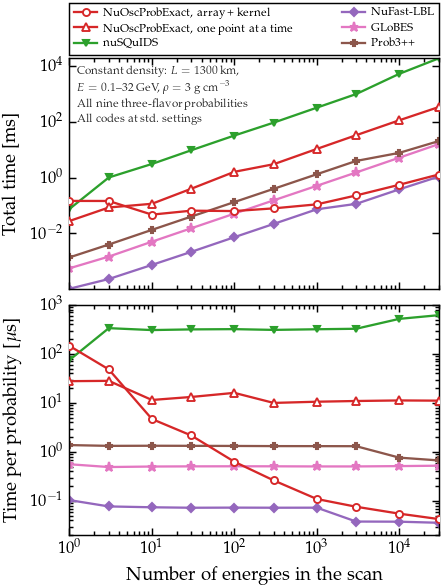

In [12]:
import time
import fastkernels


def best_of(func, repeat=5):
    # The minimum, not the mean: timing noise is one-sided, so the fastest
    # run is the one least polluted by whatever else the machine was doing.
    best = float("inf")
    for _ in range(repeat):
        t0 = time.perf_counter()
        func()
        best = min(best, time.perf_counter()-t0)
    return best


L = 1300.0*KM
sizes = [1, 3, 10, 30, 100, 300, 1000, 3000, 10000, 30000]
rows = []
for n in sizes:
    Hs = hamiltonians3nu.hamiltonian_3nu_matter(
        H_VAC_3NU, np.logspace(-1.0, 1.5, n)*GEV, gd.VCC_EARTH_CRUST)
    fastkernels.USE_NUMBA = False
    t_loop = best_of(lambda: [oscprob3nu.probabilities_3nu(h, L)
                              for h in Hs], repeat=3)
    t_array = best_of(lambda: oscprob3nu.probabilities_3nu(Hs, L))
    if fastkernels.HAVE_NUMBA:
        fastkernels.USE_NUMBA = True
        oscprob3nu.probabilities_3nu(Hs, L)          # warm the compiler
        t_numba = best_of(lambda: oscprob3nu.probabilities_3nu(Hs, L))
        fastkernels.USE_NUMBA = False
    else:
        t_numba = np.nan
    rows.append((n, t_loop, t_array, t_numba))
rows = np.array(rows)
fastkernels.USE_NUMBA = fastkernels.HAVE_NUMBA

print("%8s %12s %12s %12s" % ("N", "loop [us/pt]", "array [us/pt]",
                              "numba [us/pt]"))
for n, tl, ta, tn in rows:
    print("%8d %12.3f %12.3f %12.3f"
          % (n, tl/n*1e6, ta/n*1e6, tn/n*1e6))
print("\nat the largest N: array is %.0fx the loop, numba a further %.1fx"
      % (rows[-1, 1]/rows[-1, 2], rows[-1, 2]/rows[-1, 3]))

with open(os.path.join('..', 'tests', 'timing_other_codes.json')) as handle:
    other = json.load(handle)

fig, (axt, ax) = plt.subplots(
    2, 1, figsize=(COLW, COLW*1.30), sharex=True,
    gridspec_kw={"height_ratios": [1.0, 1.0], "hspace": 0.07})

# Two of the three routes through this library: the compiled kernel, which
# is what an installation gets, and one point at a time, which is what the
# batching is worth against.  The plain array path lies between them and is
# left out to keep the legend readable.  Marker and colour match the two
# Earth planes, so a reader tracks one code across three figures.
for col, style, size, lab in (
        (3, "-o", 3.4, "NuOscProbExact, array + kernel"),
        (1, "-^", 3.6, "NuOscProbExact, one point at a time")):
    if col == 3 and not fastkernels.HAVE_NUMBA:
        continue
    kw = dict(ms=size, color="C3", mfc="white", mew=0.9, zorder=5)
    axt.loglog(rows[:, 0], rows[:, col]*1e3, style, label=lab, **kw)
    ax.loglog(rows[:, 0], rows[:, col]/rows[:, 0]*1e6, style, **kw)

# The external codes.  None of them batches: GLoBES, Prob3++ and NuFast-LBL
# take one energy per call, so their cost per probability is flat in N, and
# that flatness is the point of the lower panel.  nuSQuIDS has a
# multiple-energy mode and still does not fall, because what it amortises is
# the solver setup and not the integration.
for key, style, col, size, lab in (
        ("nusquids", "-v", "C2", 2.6, "nuSQuIDS"),
        ("nufast_lbl", "-D", "C4", 2.4, "NuFast-LBL"),
        ("globes", "-*", "C6", 4.4, "GLoBES"),
        ("prob3pp", "-P", "C5", 3.2, "Prob3++")):
    n = np.array(other[key]["sizes"], dtype=float)
    t = np.array(other[key]["seconds"])
    axt.loglog(n, t*1e3, style, ms=size, color=col, label=lab)
    ax.loglog(n, t/n*1e6, style, ms=size, color=col)

axt.set_ylabel("Total time [ms]")
axt.text(0.02, 0.97, "Constant density:  " + r"$L = 1300$ km," + "\n"
         r"$E = 0.1$--$32$ GeV,  $\rho = 3$ g cm$^{-3}$" + "\n"
         "All nine three-flavor probabilities" + "\n"
         "All codes at std.\\ settings",
         transform=axt.transAxes, ha="left", va="top", fontsize=5.6,
         color="0.2", linespacing=1.4)
# `mode="expand"` with the anchor spanning the axes makes the legend box
# exactly as wide as the panels it sits above.
leg = axt.legend(loc="lower left", bbox_to_anchor=(0.0, 1.015, 1.0, 0.1),
                 mode="expand", ncol=2, fontsize=5.6, borderaxespad=0.0,
                 columnspacing=1.2, handlelength=2.0)
leg.get_frame().set_linewidth(0.7)
ax.set_xlim(rows[0, 0], rows[-1, 0])
ax.set_xlabel("Number of energies in the scan")
ax.set_ylabel(r"Time per probability [$\mu$s]")
ax.set_ylim(2.0e-2, 1.0e3)
fig.savefig(os.path.join(FIGDIR, "performance.pdf"), bbox_inches="tight")
plt.show()

## Comparison to the alternatives

Three ways of getting the same number at $L = 1300$ km, in constant matter:
the closed form here; **nuSQuIDS**, an independently written C++ code that
integrates the density matrix numerically; and the standard second-order
expansion in $\alpha = \Delta m^2_{21}/\Delta m^2_{31}$ and $s_{13}$ used
throughout long-baseline physics (Cervera *et al.*; Akhmedov *et al.*).

The nuSQuIDS curve is read from a frozen JSON file, generated separately by
`tests/nusquids_scan.py`, so this notebook does not need nuSQuIDS installed.

max |exact - nuSQuIDS|  = 8.9e-08
max |exact - NuFast|    = 1.5e-05
max |exact - expansion| = 6.6e-03


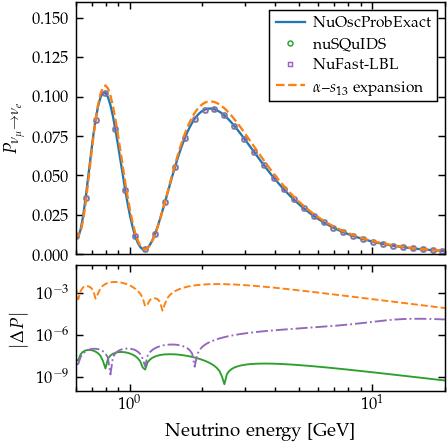

In [13]:
# P(nu_mu -> nu_e) to second order in alpha and s13, constant density:
# Akhmedov, Johansson, Lindner, Ohlsson & Schwetz, hep-ph/0402175, Eq. (32).
# Evaluated directly as the analytic expression it is -- NuOscProbExact is
# not involved, and could not be: it returns the exact answer.
def p_mue_expansion(E_ev, L, s12, s13, s23, dcp, dm21, dm31, vcc):
    c12 = np.sqrt(1.0 - s12**2.0)
    c23 = np.sqrt(1.0 - s23**2.0)
    alpha = dm21/dm31
    Delta = dm31*L/(4.0*E_ev)
    A = 2.0*vcc*E_ev/dm31
    om = 1.0 - A
    return (4.0*s13**2.0*s23**2.0*np.sin(om*Delta)**2.0/om**2.0
            + alpha*8.0*s13*s12*c12*s23*c23*np.cos(Delta + dcp)
            * np.sin(A*Delta)/A*np.sin(om*Delta)/om
            + alpha**2.0*4.0*s12**2.0*c12**2.0*c23**2.0
            * np.sin(A*Delta)**2.0/A**2.0)


with open(os.path.join('..', 'tests', 'nusquids_scan.json')) as handle:
    ref = json.load(handle)
with open(os.path.join('..', 'tests', 'nufast_scan.json')) as handle:
    nuf = json.load(handle)

E_gev = np.array(ref['energy_gev'])
E = E_gev*GEV
L_km = ref['baseline_km']
rho = ref['density_g_cm3']
L = L_km*KM
vcc = earth.matter_potential(rho)

exact = oscprob3nu.probabilities_3nu(
    hamiltonians3nu.hamiltonian_3nu_matter(H_VAC_3NU, E, vcc), L)[:, 3]
nusq = np.array(ref['probability'])
nufast = np.array(nuf['probability_N_Newton_0'])
approx = p_mue_expansion(E, L, gd.S12_NO_BF, gd.S13_NO_BF, gd.S23_NO_BF,
                         gd.DCP_NO_BF, gd.D21_NO_BF, gd.D31_NO_BF, vcc)

print("max |exact - nuSQuIDS|  = %.1e" % np.abs(exact-nusq).max())
print("max |exact - NuFast|    = %.1e" % np.abs(exact-nufast).max())
print("max |exact - expansion| = %.1e" % np.abs(exact-approx).max())

fig, (ax, axr) = plt.subplots(
    2, 1, figsize=(COLW, COLW*1.06), sharex=True,
    gridspec_kw={"height_ratios": [2.4, 1.2], "hspace": 0.06})

ax.semilogx(E_gev, exact, "-", color="C0", label="NuOscProbExact")
ax.semilogx(E_gev[::4], nusq[::4], "o", color="C2", ms=2.4, mfc="none",
            mew=0.7, label="nuSQuIDS")
ax.semilogx(E_gev[::4], nufast[::4], "s", color="C4", ms=2.2, mfc="none",
            mew=0.7, label="NuFast-LBL")
ax.semilogx(E_gev, approx, "--", color="C1", label=r"$\alpha$--$s_{13}$ expansion")
ax.set_ylabel(r"$P_{\nu_\mu \to \nu_e}$")
ax.set_ylim(0.0, 0.16)
framed(ax, loc="upper right", ncol=1)

axr.loglog(E_gev, np.abs(exact-nusq), "-", color="C2", lw=0.9,
           label="nuSQuIDS")
axr.loglog(E_gev, np.abs(exact-nufast), "-.", color="C4", lw=0.9,
           label="NuFast-LBL")
axr.loglog(E_gev, np.abs(exact-approx), "--", color="C1", lw=0.9,
           label="expansion")
axr.set_ylabel(r"$|\Delta P|$")
axr.set_xlabel("Neutrino energy [GeV]")
axr.set_xlim(E_gev[0], E_gev[-1])
axr.set_ylim(1.0e-10, 1.0e-1)
axr.set_yticks([1.0e-9, 1.0e-6, 1.0e-3])
fig.savefig(os.path.join(FIGDIR, "exact_vs_approximations.pdf"))
plt.show()

## Two flavors, four scenarios

The two-neutrino counterpart of the three-flavor figure, driven by
$\Delta m^2_{31}$ and $\theta_{23}$, over a slightly wider energy range.

Note the first argument: the builders take $\sin\theta$, not $\theta$.

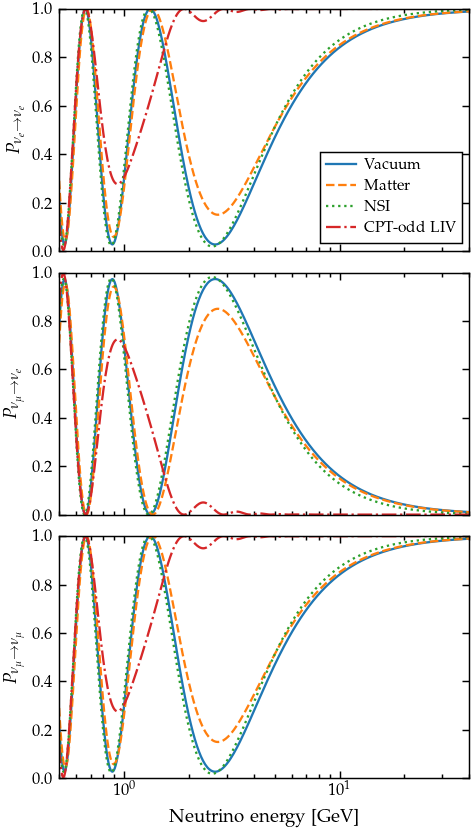

In [14]:
E_gev = np.logspace(np.log10(0.5), np.log10(40.0), 400)
E = E_gev*GEV
L = 1300.0*KM

H2_VAC = hamiltonians2nu.hamiltonian_2nu_vacuum_energy_independent(
    gd.S23_NO_BF, gd.D31_NO_BF)

p2 = {
    "Vacuum": oscprob2nu.probabilities_2nu(
        np.asarray(H2_VAC)/E[:, None, None], L),
    "Matter": oscprob2nu.probabilities_2nu(
        hamiltonians2nu.hamiltonian_2nu_matter(
            H2_VAC, E, gd.VCC_EARTH_CRUST), L),
    "NSI": oscprob2nu.probabilities_2nu(
        hamiltonians2nu.hamiltonian_2nu_nsi(
            H2_VAC, E, gd.VCC_EARTH_CRUST, gd.EPS_2), L),
    "CPT-odd LIV": oscprob2nu.probabilities_2nu(
        hamiltonians2nu.hamiltonian_2nu_liv(
            H2_VAC, E, gd.SXI12, gd.B1, gd.B3, gd.LAMBDA), L),
}

panels2 = [(0, r"$P_{\nu_e \to \nu_e}$"),
           (2, r"$P_{\nu_\mu \to \nu_e}$"),
           (3, r"$P_{\nu_\mu \to \nu_\mu}$")]

fig, axes = plt.subplots(3, 1, figsize=FIGSIZE_STACK, sharex=True)
for ax, (k, ylabel) in zip(axes, panels2):
    for (name, prob), ls in zip(p2.items(), STYLES):
        ax.semilogx(E_gev, prob[:, k], ls, label=name)
    ax.set_ylabel(ylabel)
    ax.set_xlim(E_gev[0], E_gev[-1])
    ax.set_ylim(0.0, 1.0)
framed(axes[0], loc="lower right")
axes[-1].set_xlabel("Neutrino energy [GeV]")
fig.tight_layout(pad=0.3)
fig.savefig(os.path.join(FIGDIR, "prob_2nu_vs_energy_compare.pdf"))
plt.show()